# Which soil measurement best predicts the right crop?

![Farmer in a field](farmer_in_a_field.jpg)

Soil testing costs money, so a farmer on a budget may only be able to measure one or two things. `soil_measures.csv` has 2,200 fields, each with nitrogen (`N`), phosphorous (`P`), potassium (`K`) and `ph` readings and the crop best suited to that soil (22 crops, 100 fields each).

This notebook asks two questions:

1. If only one measurement can be afforded, which one is the most informative?
2. How well can the crop be predicted from all the measurements, once redundant ones are removed?

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

crops = pd.read_csv("soil_measures.csv")
crops.head()

,N,P,K,ph,crop
0,90,42,43,6.502985,rice
1,85,58,41,7.038096,rice
2,60,55,44,7.840207,rice
3,74,35,40,6.980401,rice
4,78,42,42,7.628473,rice


## 1. Data checks

No missing values, and the classes are perfectly balanced.

In [2]:
print(crops.isna().sum(), "\n")
print("Number of crops:", crops["crop"].nunique())
print("Fields per crop:", crops["crop"].value_counts().unique())

N       0
P       0
K       0
ph      0
crop    0
dtype: int64 

Number of crops: 22
Fields per crop: [100]


In [3]:
crops.describe().round(2)

,N,P,K,ph
count,2200.00,2200.00,2200.00,2200.00
mean,50.55,53.36,48.15,6.47
std,36.92,32.99,50.65,0.77
min,0.00,5.00,5.00,3.50
25%,21.00,28.00,20.00,5.97
50%,37.00,51.00,32.00,6.43
75%,84.25,68.00,49.00,6.92
max,140.00,145.00,205.00,9.94


## 2. One feature at a time

A multinomial logistic regression is trained on each feature alone and scored with the weighted F1 on a held-out 20%. With 22 balanced classes, random guessing would score about 0.05.

In [4]:
features = ["N", "P", "K", "ph"]
X_train, X_test, y_train, y_test = train_test_split(
    crops[features], crops["crop"], test_size=0.2, random_state=42, stratify=crops["crop"]
)

single_feature_f1 = {}
for feature in features:
    model = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000))
    model.fit(X_train[[feature]], y_train)
    single_feature_f1[feature] = f1_score(y_test, model.predict(X_test[[feature]]), average="weighted")

single_feature_f1 = pd.Series(single_feature_f1).sort_values(ascending=False)
single_feature_f1.round(3)

K     0.202
P     0.140
N     0.102
ph    0.075
dtype: float64

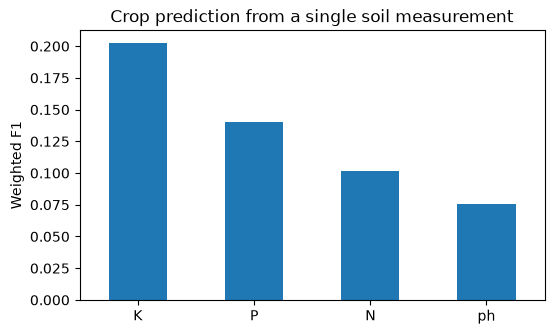

In [5]:
single_feature_f1.plot.bar(figsize=(6, 3.5))
plt.ylabel("Weighted F1")
plt.title("Crop prediction from a single soil measurement")
plt.xticks(rotation=0)
plt.show()

## 3. Multicollinearity

Highly correlated features carry overlapping information and make linear model coefficients unstable.

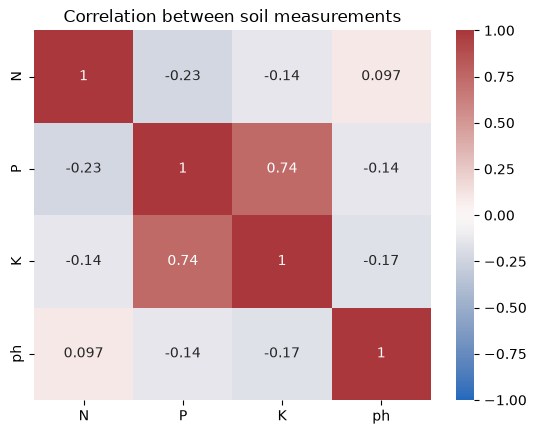

In [6]:
sns.heatmap(crops[features].corr(), annot=True, cmap="vlag", vmin=-1, vmax=1)
plt.title("Correlation between soil measurements")
plt.show()

`P` and `K` are strongly correlated (0.74). Both combinations are tried below, along with the full set for reference.

In [7]:
feature_sets = {
    "N, P, K, ph": ["N", "P", "K", "ph"],
    "N, K, ph": ["N", "K", "ph"],
    "N, P, ph": ["N", "P", "ph"],
}

results = {}
for name, cols in feature_sets.items():
    model = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000))
    model.fit(X_train[cols], y_train)
    results[name] = f1_score(y_test, model.predict(X_test[cols]), average="weighted")

pd.Series(results, name="weighted_f1").round(3)

N, P, K, ph    0.677
N, K, ph       0.500
N, P, ph       0.490
Name: weighted_f1, dtype: float64

## Findings

- Each measurement on its own is a weak predictor, though all are well above the 0.05 chance level. Potassium is the single most useful reading, so it is the one to pay for if only one test is possible.
- Combining measurements helps a great deal. `P` and `K` are correlated but not interchangeable: dropping either one costs accuracy, so the correlation is not strong enough to justify removing a feature for this model.
- Soil chemistry alone leaves a lot unexplained. Rainfall, temperature and humidity would be the obvious additions.